In [28]:
import os.path

from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from dotenv import load_dotenv
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score


In [29]:
import matplotlib.style as _ms

# Patch for mplcyberpunk expecting matplotlib.style.core
if not hasattr(_ms, "core"):
    _ms.core = _ms

import mplcyberpunk as mpl

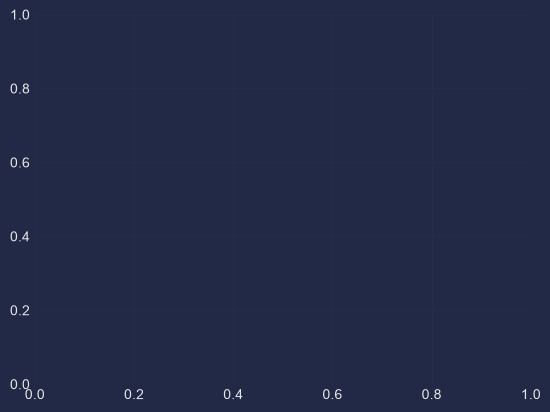

In [30]:
plt.style.use('cyberpunk')
mpl.add_glow_effects()

In [31]:
load_dotenv()

True

In [32]:
# # Download latest version
#
# path = kagglehub.competition_download('playground-series-s6e9',
#                                       output_dir='data/ev_purchase',
#                                       )
#
# print("Path to competition files:", path)

In [33]:
test = pd.read_csv('data/ev_purchase/test.csv', index_col='id')
train = pd.read_csv('data/ev_purchase/train.csv', index_col='id')

In [34]:
train.describe()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000
mean,47.039171,84769.266989,32.158298,1.712626,4.960408,7.176314,2.935477
std,12.875448,28648.029042,18.730474,0.729275,3.926843,5.186627,1.429119
min,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,36.000000,67376.000000,17.200000,1.000000,2.000000,3.000000,2.000000
50%,47.000000,84880.000000,33.600000,2.000000,4.000000,6.000000,3.000000
75%,58.000000,102753.000000,47.400000,2.000000,7.000000,10.000000,4.000000
max,69.000000,188549.000000,98.700000,4.000000,14.000000,19.000000,5.000000


In [35]:
train.head(10)

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
id,,,,,,,,,,,,,,
0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
5,50,95938.0,55.1,2,8,15,3.0,Other,Urban,Sedan,No,No,Low,No
6,55,109219.0,42.9,1,1,5,4.0,Male,Suburban,Sedan,Yes,Yes,Low,Yes
7,45,60796.0,52.2,2,13,3,2.0,Other,Urban,SUV,No,Yes,Medium,No
8,39,67725.0,31.5,2,11,3,2.0,Female,Urban,Sedan,No,Yes,Medium,No


In [36]:
cat_columns = train.select_dtypes(include=str).columns
# we need check unique values in categorical columns to see if there are any inconsistencies

train[cat_columns].nunique()

Gender                    3
City_Type                 3
Current_Car_Type          4
Home_Charging_Possible    2
Subsidy_Available         2
Range_Anxiety_Level       3
Will_Buy_EV               2
dtype: int64

In [37]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['Age',
                                   'Annual_Income_USD',
                                   'Daily_Commute_km',
                                   'Number_of_Cars_Owned',
                                   'Charging_Stations_Near_Home',
                                   'Charging_Stations_Near_Work',
                                   'Environmental_Concern_Level'
                                   ]),
        ('label', OrdinalEncoder(), ['Gender',
                                     'Home_Charging_Possible',
                                     'Subsidy_Available',
                                     'Range_Anxiety_Level']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['City_Type',
                                                         'Current_Car_Type']),
    ]
)

In [38]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100,
                                          random_state=42,
                                          n_jobs=-1))
])

In [39]:
X_train, X_val, y_train, y_val = train_test_split(
    train.drop(columns=['Will_Buy_EV']),
    train['Will_Buy_EV'],
    test_size=0.2,
    random_state=42
)

In [40]:
# save trained pipeline to disk
import joblib

model_name = 'ev_purchase_pipeline.pkl'

if os.path.exists(model_name):
    print(f'Model file {model_name} already exists. Loading the existing model.')
    pipeline = joblib.load(model_name)
else:
    print(f'Model file {model_name} does not exist. Creating a new model.')
    pipeline.fit(X_train, y_train)
    joblib.dump(pipeline, model_name)
    print("Pipeline saved to 'ev_purchase_pipeline.pkl'")

Model file ev_purchase_pipeline.pkl already exists. Loading the existing model.


In [41]:
y_pred_pipeline = pipeline.predict(X_val)
accuracy_pipeline = accuracy_score(y_val, y_pred_pipeline)
print(f"Validation Accuracy (Pipeline): {accuracy_pipeline:.4f}")

Validation Accuracy (Pipeline): 0.8938


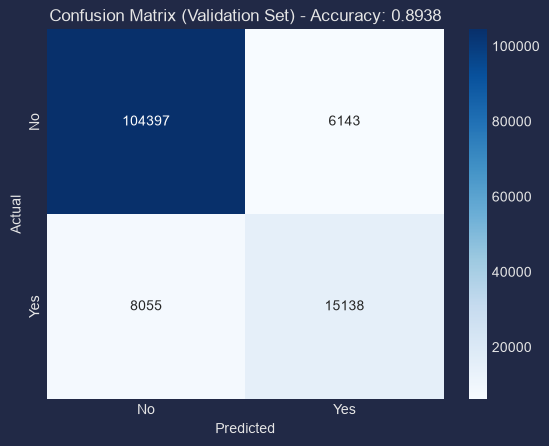

In [42]:
conf_matrix = pd.crosstab(y_val, y_pred_pipeline, rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (Validation Set) - Accuracy: {accuracy_pipeline:.4f}')
plt.show()

In [43]:
clf_report = classification_report(y_val, y_pred_pipeline)
print(clf_report)

              precision    recall  f1-score   support

          No       0.93      0.94      0.94    110540
         Yes       0.71      0.65      0.68     23193

    accuracy                           0.89    133733
   macro avg       0.82      0.80      0.81    133733
weighted avg       0.89      0.89      0.89    133733



In [44]:
# Feature importance from the Random Forest model
feature_importances = pipeline.named_steps['classifier'].feature_importances_
# Get feature names from the preprocessor
num_features = ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level']
label_features = ['Gender', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']
cat_features = pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(['City_Type', 'Current_Car_Type']).tolist()
all_features = num_features + label_features + cat_features
# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

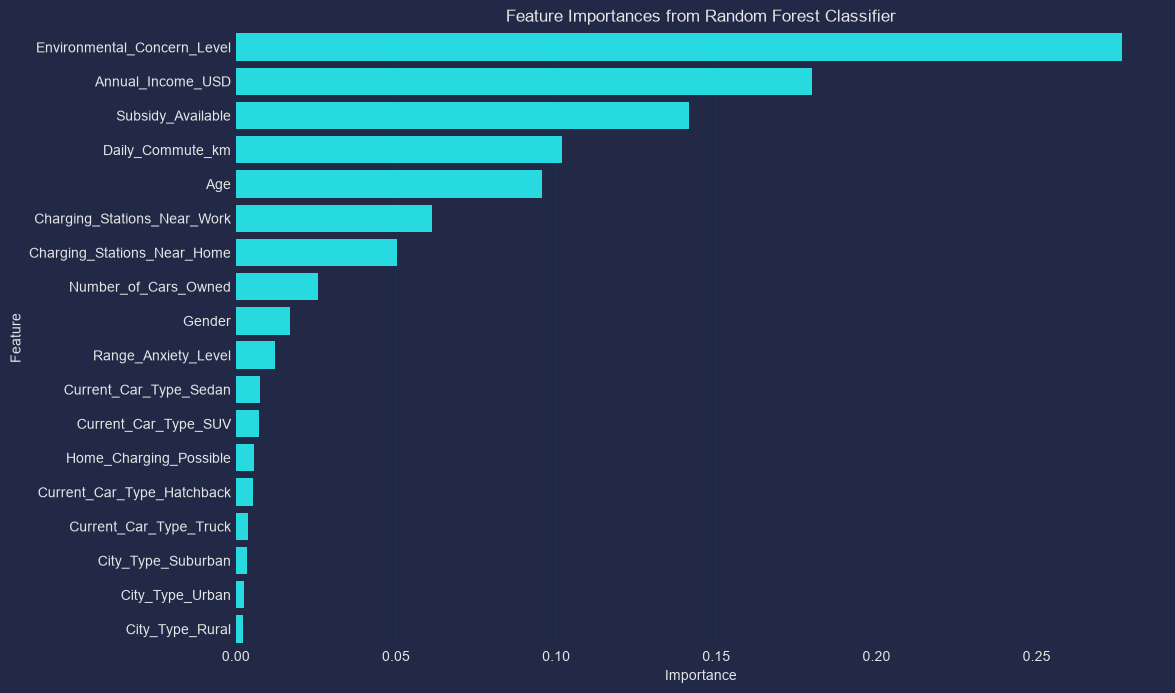

In [45]:
# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importances from Random Forest Classifier')
plt.show()

In [82]:
# let's prepare the data
# 1. use small piece of the training data ( 1000 rows ) to speed up the hyperparameter optimization process
X_train_small, _, y_train_small, _ = train_test_split(
    X_train,
    y_train,
    train_size=1000,
    random_state=42
)

# 2. Transform the small training data using the preprocessor
X_train_small_transformed = preprocessor.fit_transform(X_train_small)

In [83]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [90]:
# use Optuna to optimize hyperparameters of the Random Forest model
# {'n_estimators': 425,
#  'max_depth': 22,
#  'min_samples_split': 7,
#  'min_samples_leaf': 4}

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 10, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        # 'max_features': trial.suggest_categorical('max_features', ['auto', 'sqrt', 'log2']),
        # 'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
    }

    model = RandomForestClassifier(**params,
                                   criterion='entropy',
                                   random_state=42)
    cv_scores = cross_val_score(model,
                                X_train_small_transformed,
                                y_train_small,
                                cv=cv,
                                scoring='accuracy')
    accuracy = cv_scores.mean()

    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()

    return accuracy


In [91]:
# pruner = optuna.pruners.PatientPruner(optuna.pruners.SuccessiveHalvingPruner(), patience=10)

pruner = optuna.pruners.MedianPruner()

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42),
                            pruner=pruner)

study.optimize(objective,
               n_trials=50,
               n_jobs=-1,
               show_progress_bar=True)

print("Best hyperparameters: ", study.best_params)


[I 2026-09-14 22:36:53,047] A new study created in memory with name: no-name-bac424aa-276d-4d8a-bf8c-d13ad7b0b8d0
Best trial: 11. Best value: 0.894:   2%|▏         | 1/50 [00:10<08:39, 10.59s/it]

[I 2026-09-14 22:37:03,603] Trial 11 finished with value: 0.8939999999999999 and parameters: {'n_estimators': 179, 'max_depth': 25, 'min_samples_split': 18, 'min_samples_leaf': 2}. Best is trial 11 with value: 0.8939999999999999.


Best trial: 14. Best value: 0.897:   4%|▍         | 2/50 [00:12<04:27,  5.58s/it]

[I 2026-09-14 22:37:05,683] Trial 14 finished with value: 0.897 and parameters: {'n_estimators': 205, 'max_depth': 18, 'min_samples_split': 15, 'min_samples_leaf': 3}. Best is trial 14 with value: 0.897.


Best trial: 14. Best value: 0.897:   6%|▌         | 3/50 [00:13<02:36,  3.34s/it]

...

[I 2026-09-14 22:37:58,016] Trial 45 finished with value: 0.898 and parameters: {'n_estimators': 437, 'max_depth': 28, 'min_samples_split': 10, 'min_samples_leaf': 4}. Best is trial 37 with value: 0.9020000000000001.
[I 2026-09-14 22:37:58,089] Trial 46 finished with value: 0.9030000000000001 and parameters: {'n_estimators': 425, 'max_depth': 22, 'min_samples_split': 7, 'min_samples_leaf': 4}. Best is trial 46 with value: 0.9030000000000001.


Best trial: 46. Best value: 0.903:  94%|█████████▍| 47/50 [01:05<00:01,  1.77it/s]

[I 2026-09-14 22:37:58,294] Trial 43 finished with value: 0.8960000000000001 and parameters: {'n_estimators': 490, 'max_depth': 24, 'min_samples_split': 14, 'min_samples_leaf': 4}. Best is trial 46 with value: 0.9030000000000001.
[I 2026-09-14 22:37:58,479] Trial 44 finished with value: 0.898 and parameters: {'n_estimators': 483, 'max_depth': 22, 'min_samples_split': 13, 'min_samples_leaf': 2}. Best is trial 46 with value: 0.9030000000000001.


Best trial: 46. Best value: 0.903: 100%|██████████| 50/50 [01:05<00:00,  1.31s/it]

[I 2026-09-14 22:37:58,520] Trial 49 finished with value: 0.8969999999999999 and parameters: {'n_estimators': 427, 'max_depth': 18, 'min_samples_split': 12, 'min_samples_leaf': 4}. Best is trial 46 with value: 0.9030000000000001.
[I 2026-09-14 22:37:58,635] Trial 48 finished with value: 0.897 and parameters: {'n_estimators': 452, 'max_depth': 22, 'min_samples_split': 8, 'min_samples_leaf': 3}. Best is trial 46 with value: 0.9030000000000001.
[I 2026-09-14 22:37:58,637] Trial 47 finished with value: 0.9019999999999999 and parameters: {'n_estimators': 479, 'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 4}. Best is trial 46 with value: 0.9030000000000001.
Best hyperparameters:  {'n_estimators': 425, 'max_depth': 22, 'min_samples_split': 7, 'min_samples_leaf': 4}


In [92]:
# Visualize the optimization history
optuna.visualization.plot_optimization_history(study)

In [93]:
optuna.visualization.plot_param_importances(study)

In [94]:
optuna.visualization.plot_parallel_coordinate(study)

In [95]:
best_params = study.best_params
best_params

{'n_estimators': 425,
 'max_depth': 22,
 'min_samples_split': 7,
 'min_samples_leaf': 4}

In [96]:
score = study.best_value
print(f'Best cross-validated accuracy: {score:.4f}')

Best cross-validated accuracy: 0.9030


In [73]:
# Train the final model with the best hyperparameters
best_params = study.best_params
final_clf = RandomForestClassifier(
    **best_params,
    criterion='entropy',
    random_state=42,
    n_jobs=-1
)

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', final_clf)
])

final_pipeline.fit(X_train, y_train)
y_pred_final = final_pipeline.predict(X_val)
final_accuracy = accuracy_score(y_val, y_pred_final)
print(f'Final Model Accuracy: {final_accuracy:.4f}')

Final Model Accuracy: 0.8968
